In [1]:
import pandas as pd
import numpy as np
import os
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import subprocess as sp
from scipy.spatial import distance
from scipy.stats import hypergeom, spearmanr, mannwhitneyu
import itertools as it
from collections import Counter
import timeit

from sklearn import metrics
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
sys.path.append('/mnt/data/phenome_proj/evolution/safepy')

In [2]:
from collections import defaultdict
from scipy.stats import chi2_contingency
import seaborn as sns

In [50]:
data_dir = '/mnt/data/phenome_proj/pan_ukb/'
file_list = os.listdir(data_dir)

In [51]:
ukb_sumstat = [x for x in file_list if '.bgz' in x]
print(len(ukb_sumstat))

1263


In [5]:
var_data = pd.read_csv('/mnt/data/phenome_proj/pan_ukb/full_variant_qc_metrics.txt', sep='\t')

/tmp/ipykernel_2327882/2141056950.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  var_data = pd.read_csv('/mnt/data/phenome_proj/pan_ukb/full_variant_qc_metrics.txt', sep='\t')


In [6]:
var_data.head()

,chrom,pos,ref,alt,rsid,varid,pass_gnomad_genomes,n_passing_populations,high_quality,nearest_genes,...,gnomad_genomes_an_EAS,ac_EUR,af_EUR,an_EUR,gnomad_genomes_ac_EUR,gnomad_genomes_af_EUR,gnomad_genomes_an_EUR,ac_MID,af_MID,an_MID
0,1,11063,T,G,rs561109771,1:11063_T_G,NaN,0,False,NaN,...,NaN,47.78000,5.205600e-05,917874,NaN,NaN,NaN,7.956900,0.002391,3328
1,1,13259,G,A,rs562993331,1:13259_G_A,True,4,True,NaN,...,1528.0,247.21000,2.693300e-04,917874,0.0,0.0,8100.0,0.266670,0.000080,3328
2,1,17641,G,A,rs578081284,1:17641_G_A,NaN,0,False,NaN,...,NaN,739.46000,8.056200e-04,917874,NaN,NaN,NaN,0.501960,0.000151,3328
3,1,30741,C,A,rs558169846,1:30741_C_A,NaN,0,False,NaN,...,NaN,15.28200,1.665000e-05,917874,NaN,NaN,NaN,0.235290,0.000071,3328
4,1,51427,T,G,rs551041711,1:51427_T_G,False,4,False,NaN,...,1518.0,0.65882,7.177700e-07,917874,0.0,0.0,5438.0,0.043137,0.000013,3328


In [7]:
var_data.columns

Index(['chrom', 'pos', 'ref', 'alt', 'rsid', 'varid', 'pass_gnomad_genomes',
       'n_passing_populations', 'high_quality', 'nearest_genes', 'info',
       'ac_AFR', 'af_AFR', 'an_AFR', 'gnomad_genomes_ac_AFR',
       'gnomad_genomes_af_AFR', 'gnomad_genomes_an_AFR', 'ac_AMR', 'af_AMR',
       'an_AMR', 'gnomad_genomes_ac_AMR', 'gnomad_genomes_af_AMR',
       'gnomad_genomes_an_AMR', 'ac_CSA', 'af_CSA', 'an_CSA', 'ac_EAS',
       'af_EAS', 'an_EAS', 'gnomad_genomes_ac_EAS', 'gnomad_genomes_af_EAS',
       'gnomad_genomes_an_EAS', 'ac_EUR', 'af_EUR', 'an_EUR',
       'gnomad_genomes_ac_EUR', 'gnomad_genomes_af_EUR',
       'gnomad_genomes_an_EUR', 'ac_MID', 'af_MID', 'an_MID'],
      dtype='object')

In [8]:
rs = dict(zip([f'{x}:{y}:{r}:{a}' for x, y, r, a in zip(var_data['chrom'], 
                                                        var_data['pos'],
                                                        var_data['ref'],
                                                        var_data['alt'])], var_data['rsid']))

In [9]:
rs['1:17641:G:A']

'rs578081284'

In [52]:
work_dir = '/mnt/data/phenome_proj/evolution/pan_ukb'

In [53]:
ukb_sumstat[0]

'continuous-5117-both_sexes-irnt.tsv.bgz'

### Loading a single table to see the structure

In this section, we explore the structure of the data and column names to be used in downstream analysis funcitons/

In [17]:
test_data = pd.read_csv(f'{data_dir}/{ukb_sumstat[0]}', compression='gzip', sep='\t')
test_data.head()

/tmp/ipykernel_2307800/2827927928.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  test_data = pd.read_csv(f'{data_dir}/{ukb_sumstat[0]}', compression='gzip', sep='\t')


,chr,pos,ref,alt,af_meta,beta_meta,se_meta,neglog10_pval_meta,neglog10_pval_heterogeneity,af_AFR,...,neglog10_pval_CSA,neglog10_pval_EAS,neglog10_pval_EUR,neglog10_pval_MID,low_confidence_AFR,low_confidence_AMR,low_confidence_CSA,low_confidence_EAS,low_confidence_EUR,low_confidence_MID
0,1,11063,T,G,0.015330,0.16930,0.11820,0.8175,NaN,0.015330,...,NaN,NaN,1.5020,NaN,False,NaN,NaN,NaN,True,NaN
1,1,13259,G,A,0.000332,0.05806,0.15330,0.1519,NaN,NaN,...,NaN,NaN,0.1519,NaN,NaN,NaN,NaN,NaN,False,NaN
2,1,17641,G,A,0.000863,0.06104,0.09567,0.2811,NaN,NaN,...,NaN,NaN,0.2811,NaN,NaN,NaN,NaN,NaN,False,NaN
3,1,30741,C,A,NaN,NaN,NaN,NaN,NaN,0.003496,...,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN
4,1,51427,T,G,NaN,NaN,NaN,NaN,NaN,0.002586,...,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN


In [18]:
test_data.columns

Index(['chr', 'pos', 'ref', 'alt', 'af_meta', 'beta_meta', 'se_meta',
       'neglog10_pval_meta', 'neglog10_pval_heterogeneity', 'af_AFR', 'af_AMR',
       'af_CSA', 'af_EAS', 'af_EUR', 'af_MID', 'beta_AFR', 'beta_AMR',
       'beta_CSA', 'beta_EAS', 'beta_EUR', 'beta_MID', 'se_AFR', 'se_AMR',
       'se_CSA', 'se_EAS', 'se_EUR', 'se_MID', 'neglog10_pval_AFR',
       'neglog10_pval_AMR', 'neglog10_pval_CSA', 'neglog10_pval_EAS',
       'neglog10_pval_EUR', 'neglog10_pval_MID', 'low_confidence_AFR',
       'low_confidence_AMR', 'low_confidence_CSA', 'low_confidence_EAS',
       'low_confidence_EUR', 'low_confidence_MID'],
      dtype='object')

In [19]:
test_data.loc[test_data['low_confidence_EUR'] == False].head()

,chr,pos,ref,alt,af_meta,beta_meta,se_meta,neglog10_pval_meta,neglog10_pval_heterogeneity,af_AFR,...,neglog10_pval_CSA,neglog10_pval_EAS,neglog10_pval_EUR,neglog10_pval_MID,low_confidence_AFR,low_confidence_AMR,low_confidence_CSA,low_confidence_EAS,low_confidence_EUR,low_confidence_MID
1,1,13259,G,A,0.000332,0.05806,0.15330,0.15190,NaN,NaN,...,NaN,NaN,0.15190,NaN,NaN,NaN,NaN,NaN,False,NaN
2,1,17641,G,A,0.000863,0.06104,0.09567,0.28110,NaN,NaN,...,NaN,NaN,0.28110,NaN,NaN,NaN,NaN,NaN,False,NaN
5,1,57222,T,C,0.000665,0.10280,0.11090,0.45120,NaN,NaN,...,NaN,NaN,0.45120,NaN,NaN,NaN,NaN,NaN,False,NaN
6,1,58396,T,C,0.000305,-0.01350,0.14970,0.03239,NaN,0.002803,...,NaN,NaN,0.03239,NaN,True,NaN,NaN,NaN,False,NaN
13,1,69569,T,C,0.000230,0.14380,0.17980,0.37260,NaN,0.001398,...,NaN,NaN,0.37260,NaN,True,NaN,NaN,NaN,False,NaN


In [12]:
#workers = ProcessPoolExecutor(max_workers=16)

Here, I have re-made the function to parse pan-UKB files in order not to use `pandas`, which turned out to be extremely RAM-greedy. 

In [27]:
import gzip
import gc
def prepare_stats(pheno, rs=rs, data_dir=data_dir, worK_dir=work_dir):
    print(f'Doing {pheno}')
    with gzip.open(f'{data_dir}/{pheno}', 'rt') as input_file, open(f'{work_dir}/{pheno.replace(".bgz", "")}', 'w') as output_file:
        for line in input_file:
            content = line.strip().split('\t')
            if line.startswith('chr'):
                output_file.write('SNP\tChr\tPos\tP\n')
                for idx, col_name in enumerate(content):
                    if col_name == 'low_confidence_EUR':
                        lowconf_col = idx
                    elif col_name == 'neglog10_pval_EUR':
                        pval_col = idx
                continue
            if lowconf_col is None or pval_col is None:
                print('Trait does not have necessary cols, exiting!')
                break
            if (not content[lowconf_col] == 'false') or content[pval_col] == 'NA':
#                print(content[lowconf_col])
                continue
            rsid = rs[f'{content[0]}:{content[1]}:{content[2]}:{content[3]}']
            raw_pval = np.exp(-float(content[pval_col]))
            output_file.write(f'{rsid}\t{content[0]}\t{content[1]}\t{raw_pval}\n')
        gc.collect()
        return None


#def prepare_stats(pheno, rs=rs, data_dir=data_dir, worK_dir=work_dir):
#    print(f'Doing {pheno}')
#    sum_data = pd.read_csv(f'{data_dir}/{pheno}', compression='gzip', sep='\t')
#    sum_data['SNP'] = [rs[f'{x}:{y}:{r}:{a}'] for x, y, r, a in zip(sum_data['chr'],
#                                                                    sum_data['pos'],
#                                                                    sum_data['ref'],
#                                                                    sum_data['alt'])]
#    sum_data['Chr'] = sum_data['chr']
#    sum_data['Pos'] = sum_data['pos']
#    sum_data['P'] = np.exp(-sum_data['neglog10_pval_EUR'])
#    sum_data = sum_data.loc[sum_data['low_confidence_EUR'] == False]
#    exp_data = sum_data[['SNP', 'Chr',  'Pos', 'P']]
#    exp_data.to_csv(f'{work_dir}/{pheno.replace(".bgz", "")}', index=False, sep='\t')

In [ ]:
# Testing the function
for sumstat in ukb_sumstat:
    prepare_stats(sumstat)

Doing continuous-5117-both_sexes-irnt.tsv.bgz
Doing phecode-555-both_sexes.tsv.bgz
Doing continuous-20514-both_sexes.tsv.bgz
Doing categorical-670-both_sexes-4.tsv.bgz
Doing categorical-20001-both_sexes-1061.tsv.bgz
Doing phecode-459.9-both_sexes.tsv.bgz
Doing categorical-2463-both_sexes-2463.tsv.bgz
Doing prescriptions-dextropropoxyphene_paracetamol-both_sexes.tsv.bgz
Doing prescriptions-stimulant_laxative|laxative-both_sexes.tsv.bgz
Doing biomarkers-30690-both_sexes-irnt.tsv.bgz
Doing biomarkers-30750-both_sexes-irnt.tsv.bgz
Doing icd10-Z46-both_sexes.tsv.bgz
Doing continuous-4260-both_sexes.tsv.bgz
Doing categorical-4653-both_sexes-4653.tsv.bgz
Doing continuous-2764-both_sexes-irnt.tsv.bgz
Doing continuous-30010-both_sexes-irnt.tsv.bgz


In [47]:
final_paths = [f'{work_dir}/{x.replace(".bgz", "")}' for x in ukb_sumstat]

In [48]:
final_paths[0]

'/mnt/data/phenome_proj/evolution/pan_ukb/continuous-5117-both_sexes-irnt.tsv'

In [49]:
undone_files = [x for (x, y) in zip(ukb_sumstat, final_paths) if not os.path.isfile(y)]
len(undone_files)

0

In [ ]:
# Testing the function
for sumstat in undone_files:
    prepare_stats(sumstat)

Doing icd10-G55-both_sexes.tsv.bgz
Doing categorical-3731-both_sexes-3731.tsv.bgz
Doing phecode-411.8-both_sexes.tsv.bgz
Doing continuous-MCP-both_sexes-irnt.tsv.bgz
Doing phecode-285-both_sexes.tsv.bgz
Doing continuous-5100-both_sexes-irnt.tsv.bgz


In [ ]:
#log = workers.map(prepare_stats, ukb_sumstat)

In [31]:
len(formatted)

1264

In [38]:
formatted = [x.replace(".bgz", "") for x in ukb_sumstat]

In [39]:
formatted[0]

'continuous-5117-both_sexes-irnt.tsv'

In [45]:
def create_gene_bed(pheno, work_dir=work_dir, clumping=True, pval_cutoff='1e-8'):
    if clumping:
        clump_cmd = f'''/home/barbitoff/software/plink --bfile /mnt/data/phenome_proj/EUR_005_nodups \
                    --clump {work_dir}/{pheno} --out {work_dir}/{pheno}_plink \
                    --clump-r2 0.1 --clump-p1 {pval_cutoff} --clump-p2 1e-4 --clump-field P \
                    --allow-no-sex --allow-extra-chr'''
        status = sp.run(clump_cmd, shell=True)
    bed_cmd = f'''awk 'OFS="\t" {{ print $1,$4,$4+1,$3,$5 }}' {work_dir}/{pheno}_plink.clumped \
                         | sort -k1,1 -k2,2n | grep -vP '^\s+|CHR' > {work_dir}/{pheno}.lead.bed'''
    status = sp.run(bed_cmd, shell=True)
    gene_cmd = f'''bedtools closest -a {work_dir}/{pheno}.lead.bed \
                                    -b /mnt/data/phenome_proj/network_cleanup/gencode_formatted.bed \
                                    > {work_dir}/{pheno}.genes.bed'''
    status = sp.run(gene_cmd, shell=True)
    print(f'Done {pheno}')



In [46]:
workers = ThreadPoolExecutor(max_workers=8)

In [55]:
workers.map(create_gene_bed, formatted)

<generator object Executor.map.<locals>.result_iterator at 0x7f7b7c5413c0>

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/data/phenome_proj/evolution/pan_ukb/continuous-5117-both_sexes-irnt.tsv_plink.log.
Options in effect:
  --allow-extra-chr
  --allow-no-sex
  --bfile /mnt/data/phenome_proj/EUR_005_nodups
  --clump /mnt/data/phenome_proj/evolution/pan_ukb/continuous-5117-both_sexes-irnt.tsv
  --clump-field P
  --clump-p1 1e-8
  --clump-p2 1e-4
  --clump-r2 0.1
  --out /mnt/data/phenome_proj/evolution/pan_ukb/continuous-5117-both_sexes-irnt.tsv_plink

128626 MB RAM detected; reserving 64313 MB for main workspace.
8314989 variants loaded from .bim file.
503 people (240 males, 263 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 0%PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/pli

12 more top variant IDs missing; see log file.


Done phecode-555-both_sexes.tsv


/bin/sh: 1: laxative-both_sexes.tsv: not found
/bin/sh: 1: laxative-both_sexes.tsv_plink: not found
/bin/sh: 1: laxative-both_sexes.tsv_plink.clumped: not found
/bin/sh: 1: laxative-both_sexes.tsv.lead.bed: not found
/bin/sh: 1: laxative-both_sexes.tsv.lead.bed: not found
/bin/sh: 1: laxative-both_sexes.tsv.genes.bed: not found

Tool:    bedtools closest (aka closestBed)
Version: v2.30.0
Summary: For each feature in A, finds the closest 
	 feature (upstream or downstream) in B.

Usage:   bedtools closest [OPTIONS] -a <bed/gff/vcf> -b <bed/gff/vcf>

Options: 
	-d	In addition to the closest feature in B, 
		report its distance to A as an extra column.
		- The reported distance for overlapping features will be 0.

	-D	Like -d, report the closest feature in B, and its distance to A
		as an extra column. Unlike -d, use negative distances to report
		upstream features.
		The options for defining which orientation is "upstream" are:
		- "ref"   Report distance with respect to the reference ge

...

Done categorical-680-both_sexes-3.tsv
PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/data/phenome_proj/evolution/pan_ukb/categorical-20126-both_sexes-0.tsv_plink.log.
Options in effect:
  --allow-extra-chr
  --allow-no-sex
  --bfile /mnt/data/phenome_proj/EUR_005_nodups
  --clump /mnt/data/phenome_proj/evolution/pan_ukb/categorical-20126-both_sexes-0.tsv
  --clump-field P
  --clump-p1 1e-8
  --clump-p2 1e-4
  --clump-r2 0.1
  --out /mnt/data/phenome_proj/evolution/pan_ukb/categorical-20126-both_sexes-0.tsv_plink

128626 MB RAM detected; reserving 64313 MB for main workspace.
8314989 variants loaded from .bim file.
503 people (240 males, 263 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728

awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/icd10-F17-both_sexes.tsv_plink.clumped' for reading: No such file or directory


Done icd10-F17-both_sexes.tsv
PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/data/phenome_proj/evolution/pan_ukb/continuous-104030-both_sexes.tsv_plink.log.
Options in effect:
  --allow-extra-chr
  --allow-no-sex
  --bfile /mnt/data/phenome_proj/EUR_005_nodups
  --clump /mnt/data/phenome_proj/evolution/pan_ukb/continuous-104030-both_sexes.tsv
  --clump-field P
  --clump-p1 1e-8
  --clump-p2 1e-4
  --clump-r2 0.1
  --out /mnt/data/phenome_proj/evolution/pan_ukb/continuous-104030-both_sexes.tsv_plink

128626 MB RAM detected; reserving 64313 MB for main workspace.
8314989 variants loaded from .bim file.
503 people (240 males, 263 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 1011121314151617181920212223242526272829303132333435

1263 more top variant IDs missing; see log file.
variant.
is a top variant.
variant.
1257 more top variant IDs missing; see log file.


--clump: 145 clumps formed from 8678 top variants.
Results written to
/mnt/data/phenome_proj/evolution/pan_ukb/continuous-20153-both_sexes-irnt.tsv_plink.clumped
.
Done phecode-244.4-both_sexes.tsv
Done continuous-20153-both_sexes-irnt.tsv


In [56]:
# Function for simple trimming of stuff
def trim_proximal(gene_bed, min_distance=1000000):
    previous = (None, None)
    best_p = (-1, 1)
    trimming_step = 0
    stored_lines = []
    out_bed_name = gene_bed.replace("genes.bed", "trimmed.bed")
    with open(f'{work_dir}/{gene_bed}', 'r') as in_bed, open(f'{work_dir}/{out_bed_name}', 'w') as out_bed:
        for line in in_bed:
            content = line.strip().split('\t')
            trim_cond = (content[0] == previous[0]) and ((int(content[1]) - previous[1]) < min_distance)
            previous = (content[0], int(content[1]))
            if best_p[0] == -1:
                best_p = (0, float(content[4]))
                stored_lines = [line]
                continue
            if trim_cond:
                trimming_step += 1
                if float(content[4]) < best_p[1]:
                    best_p = (trimming_step, float(content[4]))
                stored_lines.append(line)
                continue
            else:
                trimming_step = 0
                out_bed.write(stored_lines[best_p[0]])
                best_p = (0, float(content[4]))
                stored_lines = [line]

### Optional phenotype filtering

Per criticism of the reviewers in MBE, we are undertaking an effort to filter the traits so as to keep only those that are not disease-like (i.e., keeping continuous and biomarkers only).

In [40]:
formatted[0]

'continuous-5117-both_sexes-irnt.tsv'

In [57]:
filter_traits = True
if filter_traits:
    passfilter_traits = [x for x in formatted if (x.startswith('continuous') or x.startswith('biomarker'))]
else:
    passfilter_traits = formatted
print(len(passfilter_traits))

480


In [65]:
clean_pheno_names = [x.split('-both')[0] for x in passfilter_traits  if 'both_sexes' in x]
clean_pheno_names[0]

'continuous-5117'

In [66]:
len(clean_pheno_names)

480

In [67]:
len(set(clean_pheno_names))

480

In [59]:
genes = {}
use_trimmed = False
for idx, pheno in enumerate([x for x in passfilter_traits if 'both_sexes' in x]):
    if use_trimmed:
        trim_proximal(gene_bed=f'{pheno}.genes.bed', min_distance=1000000)
        in_file = f'{work_dir}/{pheno}.trimmed.bed' 
    else:
        in_file = f'{work_dir}/{pheno}.genes.bed'
    try:
        gene_data = pd.read_csv(in_file, sep='\t', header=None)
    except:
#        print('Broke here')
        continue
    gene_data.columns = ['var_chr', 'var_pos', 'var_end', 'rsid', 'pval', 'chr', 'start', 'end', 'gene_name']
    for chrom, start, end, symbol in zip(gene_data['chr'], gene_data['start'], 
                          gene_data['end'], gene_data['gene_name']):
        if symbol not in genes:
            genes[symbol] = [symbol, chrom, start, end] + [0 for x in passfilter_traits if 'both_sexes' in x]
        genes[symbol][idx + 4] = 1
print(len(genes))
print(genes['LRP1'])
print(len(genes['LRP1']))

6799
['LRP1', 12, 57522276, 57607134, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,

In [60]:
#### Merging associations from multiple phenotypes

merge_across_traits = False
if merge_across_traits:
    window_size = 500000
    for pheno in formatted:
        in_file = f'{work_dir}/{pheno}.genes.bed'
        # Make bed file with rsID, pvalue, gene name, and <x> kb window around lead
        # Concatenate the intervals into one file and run bedtools merge with `distinct`
        # Create a dictionary of proper gene name for each rsID, selecting one gene for overlapping intervals
        # Parse all genes.bed files substituting intervals with new intervals from intervalverse
        with open(in_file, 'r') as genes_bed, open(f'{work_dir}/{pheno}.wnd.bed', 'w') as out_file:
            for line in genes_bed:
                content = line.strip().split('\t')
                int_start = max(int(int(content[1]) - window_size/2), 0)
                out_string = [content[0], f'{int_start}', 
                              f'{int(int(content[1]) + window_size/2)}', 
                              f'{content[3]}:{content[4]}:{content[8]}']
                out_file.write('\t'.join(out_string) + '\n')

    join_cmd = f'cat {work_dir}/*.wnd.bed | sort -k1,1 -k2,2n | bedtools merge -i - -c 4 -o distinct > {work_dir}/all_loci.bed'
    status = sp.run(join_cmd, shell=True)

    final_loci_set = {}
    with open(f'{work_dir}/all_loci.bed', 'r') as loci_bed:
        for line in loci_bed:
            content = line.strip().split('\t')
            rs_data = content[3].split(',')
            best_p = (1, '')
            rsids = []
            for var in rs_data:
                var_id, pval, gene_name = var.split(':')
                rsids.append(var_id)
                if float(pval) < best_p[0]:
                    best_p = (float(pval), gene_name)
            for rs in rsids: final_loci_set[rs] = best_p[1]
    print(final_loci_set['rs2748985'])

    genes = {}
    for idx, pheno in enumerate([x for x in formatted if 'both_sexes' in x]):
        try:
            gene_data = pd.read_csv(f'{work_dir}/{pheno}.genes.bed', sep='\t', header=None)
        except:
            continue
        gene_data.columns = ['var_chr', 'var_pos', 'var_end', 'rsid', 'pval', 'chr', 'start', 'end', 'gene_name']
        for chrom, start, end, rsid in zip(gene_data['chr'], gene_data['start'], 
                              gene_data['end'], gene_data['rsid']):
            symbol = final_loci_set[rsid]
            if symbol not in genes:
                genes[symbol] = [symbol, chrom, start, end] + [0 for x in formatted if 'both_sexes' in x]
            genes[symbol][idx + 4] = 1

    print(len(genes))
    print(genes['LRP1'])

In [61]:
all_genes = list(genes.values())

In [62]:
gene_matrix = np.array([x[4:] for x in all_genes])
gene_matrix

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]])

In [63]:
gene_meta = {'gene_name': [x[0] for x in all_genes],
            'chr': [x[1] for x in all_genes],
            'start': [x[2] for x in all_genes],
            'end': [x[3] for x in all_genes]}
gene_meta = pd.DataFrame(gene_meta)
gene_meta.head()

,gene_name,chr,start,end
0,TMEM57,1,25757388,25826700
1,BSND,1,55464606,55476556
2,PCSK9,1,55505221,55530525
3,RP11-101C11.1,1,55683534,55699850
4,USP1,1,62901968,62917475


In [68]:
len(clean_pheno_names)

480

In [69]:
gene_matrix.shape

(6799, 480)

In [68]:
# Genetic correlations for Neale lab v3 GWAS
#gencorr = pd.read_csv('/mnt/data/phenome_proj/imputed_v3/renum_out_corr.txt', sep='\t', header=None)

In [70]:
panukb_gc = pd.DataFrame(np.zeros((len(clean_pheno_names), len(clean_pheno_names))))
panukb_gc.columns = clean_pheno_names
panukb_gc.index = clean_pheno_names
panukb_gc.head()

,continuous-5117,continuous-20514,biomarkers-30690,biomarkers-30750,continuous-4260,continuous-2764,continuous-30010,continuous-5110,continuous-20525,continuous-20488,...,continuous-2080,continuous-3064,continuous-398,continuous-5993,continuous-20150,continuous-24007,continuous-1021,continuous-2375,continuous-20520,continuous-23118
continuous-5117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
continuous-20514,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
biomarkers-30690,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
biomarkers-30750,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
continuous-4260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


During parsing of the pan-UKB phenotype correlation data, I do the following key things:
* I take the maximum correlation for a pair of traits irrespective of the encoding and other modifications;
* I convert negative correlations to positive correlations on the fly - this action has two-fold motivation: (i) to ease calculation of distance and clustering; (ii) negative correlation between traits can still be indicative of shared genetic architecture!

In [71]:
gencorr_fname = '/mnt/data/phenome_proj/pan_ukb/Pheno_pairwise_correlations_update.txt'
with open(gencorr_fname, 'r') as gencorr_file:
    found_values = set()
    processed_rows = 0
    for line in gencorr_file:
        processed_rows += 1
        if line.startswith('i\tj'):
            continue
        content = line.strip().split('\t')
        i_pheno_name = f'{content[3]}-{content[4]}'.replace(' ', '_')
        j_pheno_name = f'{content[15]}-{content[16]}'.replace(' ', '_')
        if i_pheno_name in clean_pheno_names and j_pheno_name in clean_pheno_names:
            corr_value = abs(float(content[2]))
            if len(found_values) % 25000 == 0 and (i_pheno_name, j_pheno_name) not in found_values:
                print(f'Found {len(found_values)} values, percentage is {len(found_values)/processed_rows}.')
            found_values.add((i_pheno_name, j_pheno_name))
            if corr_value > panukb_gc.loc[i_pheno_name, j_pheno_name]:
                panukb_gc.loc[i_pheno_name, j_pheno_name] = corr_value

Found 0 values, percentage is 0.0.
Found 25000 values, percentage is 0.0002788232192422551.
Found 50000 values, percentage is 0.0005526865107505595.
Found 75000 values, percentage is 0.0008159409801820665.
Found 100000 values, percentage is 0.0010688732200388289.
Found 125000 values, percentage is 0.0013097404992288614.
Found 150000 values, percentage is 0.001550676639819354.
Found 175000 values, percentage is 0.0017709785514662458.
Found 200000 values, percentage is 0.001989833819625504.
Found 225000 values, percentage is 0.0013295265541168272.


In [72]:
len(set([x.split('-both')[0] for x in clean_pheno_names]))

480

### Filtering the data

Some of the traits that are present in the dataset are absent from the phenotype correlation matrix. Thus, we have to clean the data (both the `gene_matrix` and the `panukb_gc` from those traits, and run some additional checks.

In [73]:
bad_rows = set()
for idx, row_data in panukb_gc.iterrows():
    if sum(row_data) == 0:
#        print(idx)
        bad_rows.add(idx)
print(len(bad_rows))

bad_cols = set()
for col in panukb_gc.columns:
    if sum(panukb_gc[col]) == 0:
        bad_cols.add(col)
print(len(bad_cols))

0
0


In [74]:
bad_rows

set()

As can be seen above, the traits in the list are all in the `prescriptions` category, and manual grep-ping of these from the correlation dataset validates that they are just absent from the data. 

In [75]:
if len(bad_rows) > 0:
    cols_to_remove = []
    for idx, ph_name in enumerate(clean_pheno_names):
        if ph_name in bad_cols:
            cols_to_remove.append(idx)

In [76]:
if len(bad_rows) > 0:
    cleaned_gene_matrix = np.delete(gene_matrix, cols_to_remove, 1)
    cleaned_gene_matrix.shape

In [77]:
panukb_gc.shape

(480, 480)

In [78]:
for gc_col in panukb_gc:
    nan_vec = [np.isnan(x) for x in panukb_gc[gc_col]]
    if any(nan_vec):
        print(gc_col)
        print(sum(nan_vec))

In [79]:
gencorr = panukb_gc.copy()
for bad_col in bad_cols:
    gencorr = gencorr.drop(bad_col, axis=1)
    gencorr= gencorr.drop(bad_col, axis=0)
gencorr.shape

(480, 480)

In [80]:
gencorr.max()

continuous-5117     1.0
continuous-20514    1.0
biomarkers-30690    1.0
biomarkers-30750    1.0
continuous-4260     1.0
                   ... 
continuous-24007    1.0
continuous-1021     1.0
continuous-2375     1.0
continuous-20520    1.0
continuous-23118    1.0
Length: 480, dtype: float64

### Buuilding network corrected for $r_g$ and degree of pleiotropy

For this analysis, we first have to cluster the traits (or use pre-built clustering from the LDSC output) to remove the effects of correlated traits. To do so, we will:
* Load genetic correlation data generated earlier from LDSC;
* Find optimal clustering cutoff using silhouettes and identify clusters
* Sum columns of the `gene_matrix` to remove column-wise correlation
* Select genes with $> 2$ (or more) cross-cluster associations
* Repear network building

In [81]:
dist_rg = 1 - gencorr
dist_rg.head()

,continuous-5117,continuous-20514,biomarkers-30690,biomarkers-30750,continuous-4260,continuous-2764,continuous-30010,continuous-5110,continuous-20525,continuous-20488,...,continuous-2080,continuous-3064,continuous-398,continuous-5993,continuous-20150,continuous-24007,continuous-1021,continuous-2375,continuous-20520,continuous-23118
continuous-5117,0.000000,0.998399,0.994269,0.995581,0.999992,0.994101,0.991594,0.968923,0.998853,0.997859,...,0.991233,0.985672,0.996223,0.991159,0.988407,0.993675,0.998066,0.998425,0.996587,0.994425
continuous-20514,0.998399,0.000000,0.990668,0.994097,0.993048,0.990843,0.999494,0.997861,0.927539,0.889760,...,0.858240,0.993697,0.997141,0.994134,0.999228,0.980039,0.998304,0.998706,0.557790,0.977905
biomarkers-30690,0.994269,0.990668,0.000000,0.961378,0.996356,0.970480,0.995414,0.993250,0.992642,0.987369,...,0.961645,0.936912,0.971490,0.978931,0.924603,0.954406,0.991874,0.980830,0.999539,0.824960
biomarkers-30750,0.995581,0.994097,0.961378,0.000000,0.978460,0.954332,0.929704,0.993167,0.980011,0.997462,...,0.954006,0.878500,0.940909,0.931503,0.848320,0.980948,0.995978,0.979483,0.991332,0.924455
continuous-4260,0.999992,0.993048,0.996356,0.978460,0.000000,0.985598,0.998824,0.999982,0.989262,0.995734,...,0.984877,0.963617,0.992735,1.000000,0.969452,0.988436,0.996977,0.992334,0.992268,0.984263


In [82]:
for gc_col in dist_rg:
    nan_vec = [np.isnan(x) for x in gencorr[gc_col]]
    if any(nan_vec):
        print(gc_col)
        print(sum(nan_vec))

In [85]:
clustering = AgglomerativeClustering(n_clusters=2, affinity='precomputed',
            compute_full_tree=True, memory='tmp', linkage='average').fit(dist_rg)

scores = []
for i in range(50, round(0.8 * len(clean_pheno_names)), 1):
#     start_time = time.time()
    
    i = int(i)
    clustering.set_params(n_clusters=i)
    clusters = clustering.fit_predict(dist_rg)
    score = silhouette_score(dist_rg, clusters)
    scores.append(score)
    if i % 10 == 0:
        print(f'{i}: {score:.4f}')
#     print(f'{time.time() - start_time:.4f}')

50: 0.0110
60: 0.0566
70: 0.0868
80: 0.1132
90: 0.1457
100: 0.1732
110: 0.1938
120: 0.1935
130: 0.2077
140: 0.2167
150: 0.2263
160: 0.2378
170: 0.2383
180: 0.2491
190: 0.2469
200: 0.2516
210: 0.2822
220: 0.2800
230: 0.2705
240: 0.2778
250: 0.2690
260: 0.2724
270: 0.2657
280: 0.2612
290: 0.2507
300: 0.2460
310: 0.2326
320: 0.2242
330: 0.2217
340: 0.2142
350: 0.2110
360: 0.2066
370: 0.1932
380: 0.1645


In [86]:
optimal_n = np.argmax(scores) + 50
optimal_n

212

In [87]:
clustering.set_params(n_clusters=optimal_n)
clusters = clustering.fit_predict(dist_rg)

In [88]:
np.apply_along_axis(np.prod, 1, gene_matrix[:,[2, 8]])

array([0, 0, 0, ..., 0, 0, 0])

In [89]:
#matrix_names = []
#with open('/mnt/data/phenome_proj/imputed_v3/names.txt', 'r') as name_file:
#    for line in name_file:
#        matrix_names.append(line.strip().replace('-', '_'))
#print(sum([x in clean_pheno_names for x in matrix_names]))

#pheno_names = [matrix_names[idx] for idx, n in enumerate(clusters) if n == 74]

In [90]:
print(clusters)

[ 33   5 105 210  68 154  12   0 194  14 181  12  37 155  12   6  55 104
  91  78 189 147  32  13  82  14 108  74 116  72  82   3  12  65  78  16
  49  20   9  74 127  87  25 103  33  82  16  27  30  98  12  20  31  66
 184 204  20 107 171 135  48 169 187 186  68  17  47 143  12  12 106 188
 124  97   7   3 104   8   5  25 176  10  25  90 159  19  94  45  70   6
 113  44 174  84  36  15  38 167  24   5  78   5  25 162  25  65 126  36
   1  46  43 141  27  50  43  41  46 144 105 102  31 139  34 157  30 145
  88 205  25  63  46 170 207  12 173  40 137  25   5  25 166 101  48  12
  12 110  61  21 178 150  27  41  18  33  72 195  85  35  12  45 201  12
  12 129 103  46  45 164  94   9  12  35  63  47  71  49  72  21  72 105
   8  11 153  15  47   0 114  90  46  12  45  63  12  12  86 102  22 152
 160  12  12  22  72 175 206 121 122   1  50  94  63  42  51  30  33  90
  87  41  25  87  26  20  25  88 151 161 168  20 197 180  86  12 185  52
   5 115  57 206  63  80 191  94 117   7  12  11   

In [91]:
with open('/mnt/data/phenome_proj/evolution/panukb_clusters.txt', 'w') as cluster_log:
    cluster_log.write('pheno_name\tcluster\n')
    for idx, n in enumerate(clusters):
        cluster_log.write(f'{clean_pheno_names[idx]}\t{n}\n')

In [92]:
merged = []
for i in range(optimal_n):
    pheno_names = [clean_pheno_names[idx] for idx, n in enumerate(clusters) if n == i]
    if 'continuous-21001' in pheno_names:
        print(pheno_names)
    pheno_idx = [idx for idx, pheno_name in enumerate(clean_pheno_names) if pheno_name in pheno_names]
    gene_cluster = np.apply_along_axis(lambda x: 1 if 1 in x else 0, 1, gene_matrix[:,pheno_idx])
    merged.append(gene_cluster)
gene_cluster_matrix = np.array(merged).T
gene_cluster_matrix.shape

['continuous-49', 'continuous-23124', 'continuous-23128', 'continuous-23120', 'continuous-23123', 'continuous-23116', 'continuous-23099', 'continuous-21001', 'continuous-23127', 'biomarkers-30710', 'continuous-23100', 'continuous-23115', 'continuous-23119', 'continuous-23112', 'continuous-23104', 'continuous-23111']


(6799, 212)

In [93]:
for i in range(20):
    print(f'{i}: {Counter(np.apply_along_axis(lambda x: 1 if sum(x) > i else 0, 1, gene_cluster_matrix))[1]}')

0: 6799
1: 2880
2: 1442
3: 849
4: 537
5: 349
6: 228
7: 167
8: 118
9: 94
10: 71
11: 55
12: 47
13: 34
14: 25
15: 20
16: 17
17: 13
18: 10
19: 6


In [94]:
def hla_checker(gene_idx, gene_meta=gene_meta):
    try:
        this_gene = gene_meta.iloc[gene_idx]
#        print(this_gene)
    except:
        print(f'Error at idx {gene_idx}')
    if str(this_gene['chr']) == '6' and this_gene['start'] > 27500000 and this_gene['end'] < 35000000:
        return False
    else:
#        print(type(this_gene['chr']))
        return True

In [95]:
gene_meta.loc[gene_meta['gene_name'] == 'HLA-A']

,gene_name,chr,start,end
666,HLA-A,6,29909037,29913661


In [96]:
hla_checker(673)

False

In [97]:
Counter([hla_checker(x) for x in range(len(gene_cluster_matrix))])

Counter({True: 6470, False: 329})

In [98]:
pleio_genes = [idx for idx, gene in enumerate(gene_cluster_matrix) if (sum(gene) > 1 and hla_checker(idx))]
len(pleio_genes)

2613

In [99]:
non_hla_genes = [idx for idx, gene in enumerate(gene_cluster_matrix) if hla_checker(idx)]
len(non_hla_genes)

6470

In [100]:
non_hla_matrix = gene_cluster_matrix[non_hla_genes, :]

In [101]:
non_hla_matrix.shape

(6470, 212)

In [102]:
non_hla_meta = gene_meta.iloc[non_hla_genes, :].copy()

In [103]:
non_hla_meta.shape

(6470, 4)

In [104]:
non_hla_meta['pleio_degree'] = np.apply_along_axis(sum, 1, non_hla_matrix)

In [105]:
non_hla_meta.to_csv('/mnt/data/phenome_proj/evolution/non_hla_panukb_pleiotropy.tsv', sep='\t', index=False)

In [106]:
gene_meta['pleio_degree'] = np.apply_along_axis(sum, 1, gene_cluster_matrix)
gene_meta.head()

,gene_name,chr,start,end,pleio_degree
0,TMEM57,1,25757388,25826700,5
1,BSND,1,55464606,55476556,1
2,PCSK9,1,55505221,55530525,1
3,RP11-101C11.1,1,55683534,55699850,1
4,USP1,1,62901968,62917475,5


In [107]:
gnomad_file = '/mnt/data/phenome_proj/evolution/gnomad.v2.1.1.lof_metrics.by_gene.txt'
cons_data = pd.read_csv(gnomad_file, sep='\t')
cons_data.head()

,gene,transcript,obs_mis,exp_mis,oe_mis,mu_mis,possible_mis,obs_mis_pphen,exp_mis_pphen,oe_mis_pphen,...,gene_type,gene_length,exac_pLI,exac_obs_lof,exac_exp_lof,exac_oe_lof,brain_expression,chromosome,start_position,end_position
0,MED13,ENST00000397786,871,1117.80,0.77921,0.000056,14195,314.0,529.75,0.59273,...,protein_coding,122678,1.0,0.0,64.393,0.000000,NaN,17,60019966,60142643
1,NIPBL,ENST00000282516,846,1441.50,0.58688,0.000074,18540,158.0,543.10,0.29092,...,protein_coding,189655,1.0,1.0,110.570,0.009044,NaN,5,36876861,37066515
2,SMC3,ENST00000361804,178,630.07,0.28251,0.000032,8109,21.0,182.52,0.11506,...,protein_coding,36946,1.0,0.0,58.523,0.000000,NaN,10,112327449,112364394
3,CNOT1,ENST00000317147,561,1295.90,0.43290,0.000069,15670,51.0,290.68,0.17545,...,protein_coding,109936,1.0,3.0,90.130,0.033285,NaN,16,58553855,58663790
4,RLF,ENST00000372771,669,972.87,0.68766,0.000047,12682,107.0,321.14,0.33319,...,protein_coding,79549,1.0,0.0,43.607,0.000000,NaN,1,40627045,40706593


In [108]:
loeuf = {k: v for k, v in zip(cons_data['gene'], cons_data['oe_lof_upper'])}
pli = {k: v for k, v in zip(cons_data['gene'], cons_data['pLI'])}

In [109]:
loeuf = defaultdict(lambda: None, loeuf)
pli = defaultdict(lambda: None, pli)

In [110]:
pli['LRP1']

1.0

In [111]:
gene_meta['LOEUF'] = [loeuf[x] for x in gene_meta['gene_name']]
gene_meta['pLI'] = [pli[x] for x in gene_meta['gene_name']]
gene_meta.head()

,gene_name,chr,start,end,pleio_degree,LOEUF,pLI
0,TMEM57,1,25757388,25826700,5,0.259,9.975700e-01
1,BSND,1,55464606,55476556,1,1.780,1.094900e-10
2,PCSK9,1,55505221,55530525,1,1.341,2.705900e-17
3,RP11-101C11.1,1,55683534,55699850,1,NaN,NaN
4,USP1,1,62901968,62917475,5,0.257,9.969100e-01


Removing HLA genes for consistency with earlier works (and given the LD porblems in MHC):

In [112]:
oemis = {k: v for k, v in zip(cons_data['gene'], cons_data['oe_mis'])}
oemis = defaultdict(lambda: None, oemis)
gene_meta['oe_mis'] = [oemis[x] for x in gene_meta['gene_name']]

In [113]:
non_hla_annotated = gene_meta.iloc[non_hla_genes, :].copy()

In [114]:
Counter([np.isnan(x) for x in non_hla_annotated['LOEUF']])

Counter({False: 4237, True: 2233})

### Plotting the results

First, we will explore the relationship between the metrics and the pleiotropy degree for a gene in two ways:
* By drawing hexplots;
* By computing the Spearman's $r$

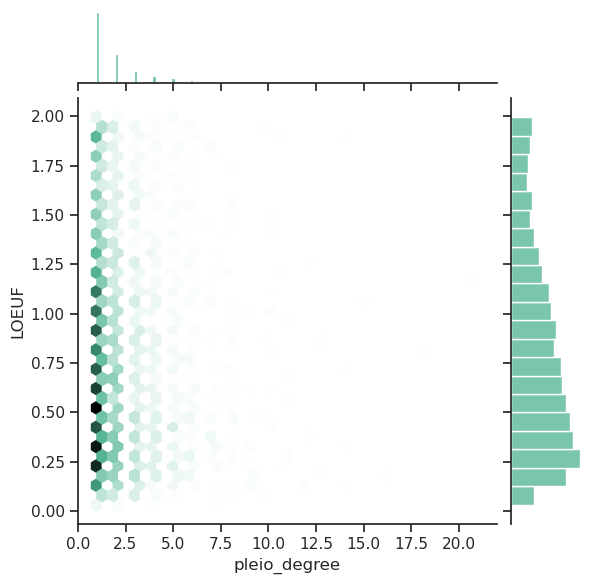

In [115]:
sns.set_theme(style="ticks")
sns.jointplot(x=non_hla_annotated['pleio_degree'], y=non_hla_annotated['LOEUF'], 
              kind="hex", color="#4CB391")

In [116]:
spearmanr(non_hla_annotated['pleio_degree'], non_hla_annotated['LOEUF'], nan_policy='omit')

SpearmanrResult(correlation=-0.09954675274091047, pvalue=8.361754748726319e-11)

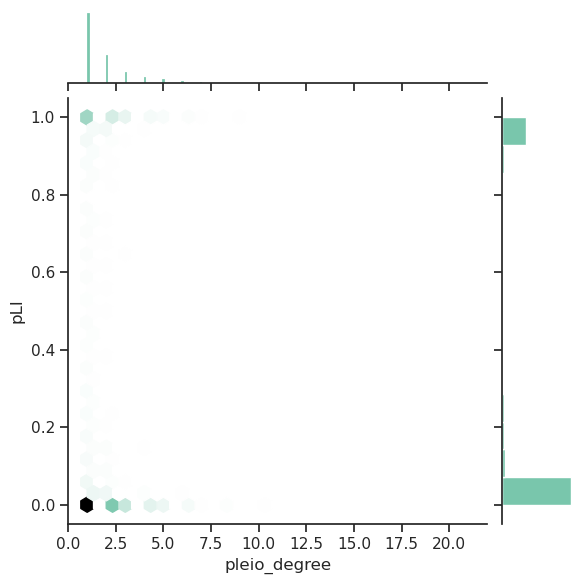

In [117]:
sns.jointplot(x=non_hla_annotated['pleio_degree'], y=non_hla_annotated['pLI'], 
              kind="hex", color="#4CB391")

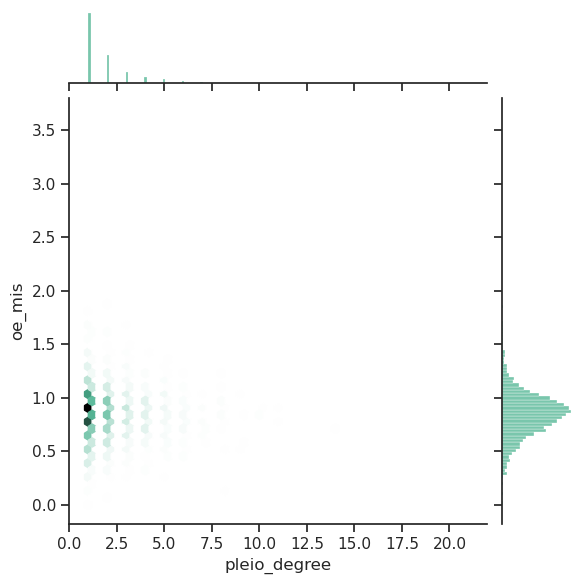

In [118]:
sns.jointplot(x=non_hla_annotated['pleio_degree'], y=non_hla_annotated['oe_mis'], 
              kind="hex", color="#4CB391")

In [119]:
spearmanr(non_hla_annotated['pleio_degree'], non_hla_annotated['oe_mis'], nan_policy='omit')

SpearmanrResult(correlation=-0.03432834477961462, pvalue=0.025019948116933595)

The results indicate no significant relationship with the missense variant ratio, however, there is a strong significant association between LOEUF and pleiotropy.

Next, we will look into the constrint metrics for pleiotropic and non-pleiotropic gnees. We will do it in three different ways:
1. Comparing the metric values for pleiotropic and non-pleiotropic genes;
2. Comparing the values for non-pleiotropic, modertate, and highly pleiotropic genes;
3. Looking into the degree of pleiotropic for LoF-tolerant and LoF-intolerant genes

#### Two-group pleiotropy analysis

Pleiotropic genes = all genes with $> 1$ cluster.

<AxesSubplot:xlabel='pleiotropic', ylabel='pLI'>

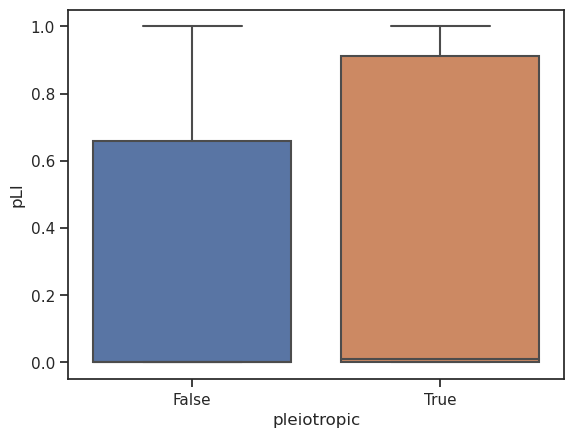

In [120]:
non_hla_annotated['pleiotropic'] = [x > 1 for x in non_hla_annotated['pleio_degree']]
sns.boxplot(data=non_hla_annotated, x="pleiotropic", y="pLI")

In [121]:
pli_means = non_hla_annotated.groupby(['pleiotropic'])['pLI'].mean()
pli_means

pleiotropic
False    0.281272
True     0.334968
Name: pLI, dtype: float64

<AxesSubplot:xlabel='pleiotropic', ylabel='LOEUF'>

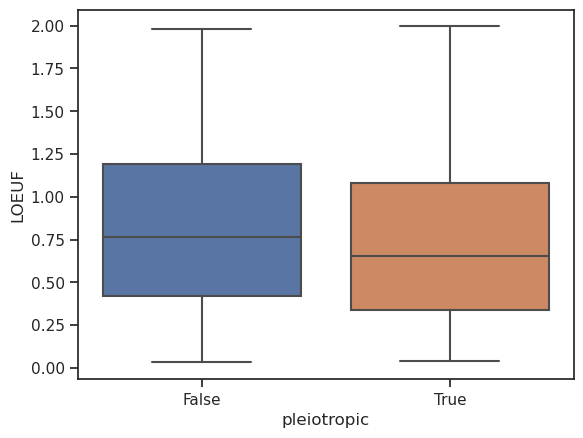

In [122]:
sns.boxplot(data=non_hla_annotated, x="pleiotropic", y="LOEUF")

In [123]:
leouf_medians = non_hla_annotated.groupby(['pleiotropic'])['LOEUF'].median()
leouf_medians

pleiotropic
False    0.765
True     0.652
Name: LOEUF, dtype: float64

In [124]:
pleio_genes = non_hla_annotated.loc[non_hla_annotated['pleiotropic'] == True]
nonpleio_genes = non_hla_annotated.loc[non_hla_annotated['pleiotropic'] == False]

In [125]:
mannwhitneyu(pleio_genes['LOEUF'], nonpleio_genes['LOEUF'], nan_policy='omit')

MannwhitneyuResult(statistic=1970306.0, pvalue=7.56455999167098e-10)

#### Three way pleiotropy analysis

Moderate pleiotropy - 2-4 associated trait clusters, high degree of pleiotropy - 5 and more associated clusters, non-pleiotropic genes - strictly one cluster (principle similar to grouping of loci from Shikov et al., 2020)

In [126]:
def emit_class(pdeg):
    if pdeg >= 5:
        return 'high'
    elif pdeg > 1:
        return 'moderate'
    return 'non-pleiotropic'

In [127]:
non_hla_annotated['three_way_pleiotropic'] = [emit_class(x) for x in non_hla_annotated['pleio_degree']]

<AxesSubplot:xlabel='three_way_pleiotropic', ylabel='LOEUF'>

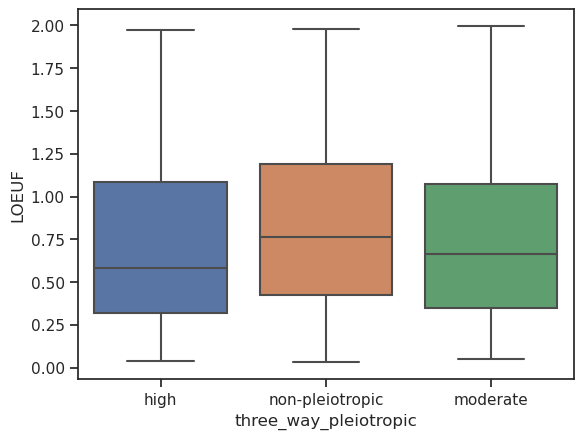

In [128]:
sns.boxplot(data=non_hla_annotated, x="three_way_pleiotropic", y="LOEUF")

In [129]:
loeuf_medians = non_hla_annotated.groupby(['three_way_pleiotropic'])['LOEUF'].median()
loeuf_medians

three_way_pleiotropic
high               0.5825
moderate           0.6645
non-pleiotropic    0.7650
Name: LOEUF, dtype: float64

#### LoF tolerance grouping.

Below, we will split the genes into categories based on their pLI values, and then compare the frequency of LoF-tolerant and intolerant genes among pleiotropic and non-pleiotropic ones

In [130]:
def is_lof_tolerant(pli_val):
    if np.isnan(pli_val):
        return None
    else:
        return (pli_val < 0.5)
non_hla_annotated['LoF_tolerant'] = [is_lof_tolerant(x) for x in non_hla_annotated['pLI']]

<AxesSubplot:xlabel='LoF_tolerant', ylabel='pleio_degree'>

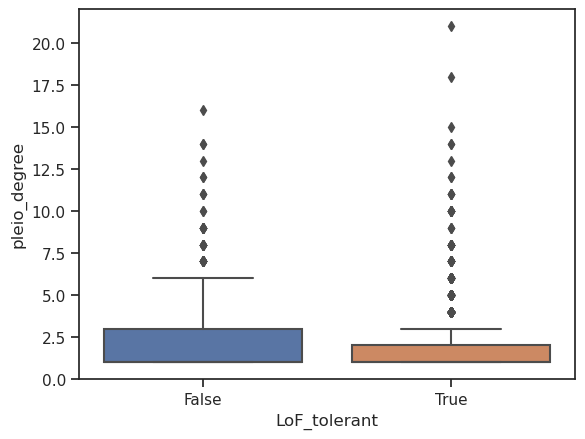

In [131]:
sns.boxplot(data=non_hla_annotated, x="LoF_tolerant", y="pleio_degree")

In [132]:
tol_cnt = Counter(zip(non_hla_annotated['pleiotropic'], non_hla_annotated['LoF_tolerant']))
tol_cnt

Counter({(True, False): 627,
         (False, True): 1709,
         (False, None): 1492,
         (True, True): 1245,
         (False, False): 656,
         (True, None): 741})

In [133]:
pleio_cons = np.array([[tol_cnt[(True, True)], tol_cnt[(True, False)]], 
                       [tol_cnt[(False, True)], tol_cnt[(False, False)]]])

In [134]:
print(pleio_cons)

[[1245  627]
 [1709  656]]


In [135]:
chi2_contingency(pleio_cons)

(16.12539190779164,
 5.928383873921568e-05,
 1,
 array([[1305.14231768,  566.85768232],
        [1648.85768232,  716.14231768]]))

Another intriguing question is the proportion of non-coding genes among pleiotropic and non-pleiotropic loci. Let's test

In [136]:
pleio_prot = np.array([[tol_cnt[(True, True)] + tol_cnt[(True, False)], tol_cnt[(True, None)]], 
                       [tol_cnt[(False, True)] + tol_cnt[(False, False)], tol_cnt[(False, None)]]])

In [137]:
pleio_prot

array([[1872,  741],
       [2365, 1492]])

In [138]:
chi2_contingency(pleio_prot)

(73.0124458406628,
 1.2883484172190975e-17,
 1,
 array([[1711.17171561,  901.82828439],
        [2525.82828439, 1331.17171561]]))

*NB* Indeed, we see that the proportion of genes that have a pLI value is greater among pleiotropic than non-pleiotropic genes. However, this is not a perfect way to test it, becayse some coding genes also do not have a pLI value in gnomAD. It is necessary to include genome annotation to run an explicit test!

## Pleiotropy analysis using `max-indep-set`

Besides definition of pleiotropy in the clustered dataset, we may want to utilize the maximum independent set of pan-UKB traits that is provided by the dataset authors. Let's try...

In [139]:
panukb_manifest = pd.read_csv('/mnt/data/phenome_proj/pan_ukb/pan_ukb_manifest.tsv', sep='\t')
panukb_manifest.head()

,trait_type,phenocode,pheno_sex,coding,modifier,description,description_more,coding_description,category,n_cases_full_cohort_both_sexes,...,aws_link_tabix,wget,wget_tabix,md5_hex,size_in_bytes,md5_hex_tabix,size_in_bytes_tabix,trait_efos,trait_efo_terms,trait_efo_categories
0,biomarkers,30600,both_sexes,NaN,irnt,Albumin,NaN,NaN,Biological samples > Assay results > Blood ass...,385205,...,https://pan-ukb-us-east-1.s3.amazonaws.com/sum...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,b656fcf77aea5019197489593bcc2954,2282017915,daa278e77542009a259c2382da9c0e1e,2242763,EFO_0004535,serum albumin measurement,Other measurement
1,biomarkers,30610,both_sexes,NaN,irnt,Alkaline phosphatase,NaN,NaN,Biological samples > Assay results > Blood ass...,420633,...,https://pan-ukb-us-east-1.s3.amazonaws.com/sum...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,13dfceb4d5afb796a7150bb3dfe21383,2300660491,a5cb98c15b84c3620f064addf1ba847b,2237400,EFO_0004533,alkaline phosphatase measurement,Liver enzyme measurement
2,biomarkers,30620,both_sexes,NaN,irnt,Alanine aminotransferase,NaN,NaN,Biological samples > Assay results > Blood ass...,420449,...,https://pan-ukb-us-east-1.s3.amazonaws.com/sum...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,cbae883df0188bbef297b69b5c52cdd0,2287738484,ef5b5fbb24bb48cd8f2c5e3f79ec2437,2243350,EFO_0004735,serum alanine aminotransferase measurement,Liver enzyme measurement
3,biomarkers,30630,both_sexes,NaN,irnt,Apolipoprotein A,NaN,NaN,Biological samples > Assay results > Blood ass...,382929,...,https://pan-ukb-us-east-1.s3.amazonaws.com/sum...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,6146cc6808d00eaa67cbe0405ff74a31,2292154115,b9d7d3f278123c43fc14c527b570d66e,2236284,EFO_0004614,apolipoprotein a 1 measurement,Lipid or lipoprotein measurement
4,biomarkers,30640,both_sexes,NaN,irnt,Apolipoprotein B,NaN,NaN,Biological samples > Assay results > Blood ass...,418505,...,https://pan-ukb-us-east-1.s3.amazonaws.com/sum...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,wget https://pan-ukb-us-east-1.s3.amazonaws.co...,1d67087ee0ed01f55de8b4f57e06701d,2287356987,d857494f8bb5d0a90e2ee6c771ab36a2,2236257,EFO_0004615,apolipoprotein B measurement,Lipid or lipoprotein measurement


In [140]:
panukb_manifest['in_max_independent_set'].head()

0    True
1    True
2    True
3    True
4    True
Name: in_max_independent_set, dtype: bool

In [141]:
maxindep_phens = set()
for idx, rdat in panukb_manifest.iterrows():
    if rdat['in_max_independent_set']:
        maxindep_phens.add(f'{rdat["trait_type"]}-{rdat["phenocode"].replace(" ", "_").replace("/", "_")}')
print(len(maxindep_phens))

139


In [142]:
maxindep_phens_idx = [idx for idx, pheno_name in enumerate(clean_pheno_names) if pheno_name in maxindep_phens]
print(len(maxindep_phens_idx))

86


Checking why one of the phenotypes is missing from the dataset that was collected

In [143]:
for iph in maxindep_phens:
    if iph not in clean_pheno_names:
        ptype, pcode = iph.split('-')
        for _, rdat in pd.read_csv('/mnt/data/phenome_proj/pan_ukb/pan_ukb_h2.tsv', sep='\t').iterrows():
            if rdat['trait_type'] == ptype and rdat['phenocode'] == pcode and rdat['pop'] == 'EUR': 
                print(rdat['estimates.final.h2_z'])
                print(rdat['pheno_sex'])

/tmp/ipykernel_3516833/3110948476.py:4: DtypeWarning: Columns (3,4,47) have mixed types. Specify dtype option on import or set low_memory=False.
  for _, rdat in pd.read_csv('/mnt/data/phenome_proj/pan_ukb/pan_ukb_h2.tsv', sep='\t').iterrows():


10.3
both_sexes
3.27
both_sexes
4.79
both_sexes
6.0
both_sexes
12.8
both_sexes
9.95
both_sexes


/tmp/ipykernel_3516833/3110948476.py:4: DtypeWarning: Columns (3,4,47) have mixed types. Specify dtype option on import or set low_memory=False.
  for _, rdat in pd.read_csv('/mnt/data/phenome_proj/pan_ukb/pan_ukb_h2.tsv', sep='\t').iterrows():
/tmp/ipykernel_3516833/3110948476.py:4: DtypeWarning: Columns (3,4,47) have mixed types. Specify dtype option on import or set low_memory=False.
  for _, rdat in pd.read_csv('/mnt/data/phenome_proj/pan_ukb/pan_ukb_h2.tsv', sep='\t').iterrows():


4.58
both_sexes
4.96
both_sexes


/tmp/ipykernel_3516833/3110948476.py:4: DtypeWarning: Columns (3,4,47) have mixed types. Specify dtype option on import or set low_memory=False.
  for _, rdat in pd.read_csv('/mnt/data/phenome_proj/pan_ukb/pan_ukb_h2.tsv', sep='\t').iterrows():
/tmp/ipykernel_3516833/3110948476.py:4: DtypeWarning: Columns (3,4,47) have mixed types. Specify dtype option on import or set low_memory=False.
  for _, rdat in pd.read_csv('/mnt/data/phenome_proj/pan_ukb/pan_ukb_h2.tsv', sep='\t').iterrows():


...

/tmp/ipykernel_3516833/3110948476.py:4: DtypeWarning: Columns (3,4,47) have mixed types. Specify dtype option on import or set low_memory=False.
  for _, rdat in pd.read_csv('/mnt/data/phenome_proj/pan_ukb/pan_ukb_h2.tsv', sep='\t').iterrows():


26.5
both_sexes
20.5
both_sexes
21.9
both_sexes
12.7
both_sexes
6.8
both_sexes
5.45
both_sexes
12.7
both_sexes
5.51
both_sexes


/tmp/ipykernel_3516833/3110948476.py:4: DtypeWarning: Columns (3,4,47) have mixed types. Specify dtype option on import or set low_memory=False.
  for _, rdat in pd.read_csv('/mnt/data/phenome_proj/pan_ukb/pan_ukb_h2.tsv', sep='\t').iterrows():


7.85
both_sexes


/tmp/ipykernel_3516833/3110948476.py:4: DtypeWarning: Columns (3,4,47) have mixed types. Specify dtype option on import or set low_memory=False.
  for _, rdat in pd.read_csv('/mnt/data/phenome_proj/pan_ukb/pan_ukb_h2.tsv', sep='\t').iterrows():


A review of the trait selection code shows that the likely problem is that we've used phenotype code without trait type when selecting the traits to be downloaded with the maximum $h^2$ score.

What can we do about it? Either we can ignore these cases, thinking that trait code is of more importance compared to type (i.e., if there are several tyoes of denoting the same field in UKB) or try to re-fetch missing data and re-run the pipeline. For now, we will proceed without changes.

In [144]:
maxindep_matrix = gene_matrix[:, maxindep_phens_idx]
maxindep_matrix.shape

(6799, 86)

In [145]:
maxindep_matrix = maxindep_matrix[non_hla_genes, :]
maxindep_matrix.shape

(6470, 86)

In [146]:
non_hla_meta['pleio_degree_maxindep'] = np.sum(maxindep_matrix, axis=1)
non_hla_annotated['pleio_degree_maxindep'] = np.sum(maxindep_matrix, axis=1)
non_hla_meta.head()

,gene_name,chr,start,end,pleio_degree,pleio_degree_maxindep
0,TMEM57,1,25757388,25826700,5,6
1,BSND,1,55464606,55476556,1,4
2,PCSK9,1,55505221,55530525,1,4
3,RP11-101C11.1,1,55683534,55699850,1,4
4,USP1,1,62901968,62917475,5,5


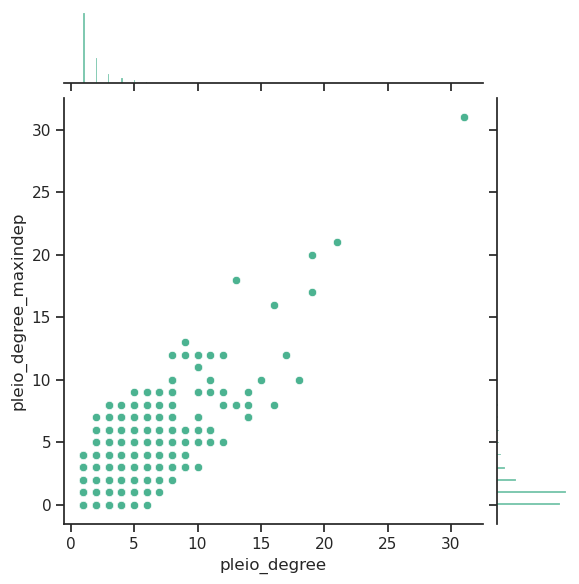

In [147]:
sns.set_theme(style="ticks")
sns.jointplot(x=non_hla_meta['pleio_degree'], y=non_hla_meta['pleio_degree_maxindep'], 
              kind="scatter", color="#4CB391")

In [148]:
spearmanr(non_hla_meta['pleio_degree'], non_hla_meta['pleio_degree_maxindep'], nan_policy='omit')

SpearmanrResult(correlation=0.5864237642186679, pvalue=0.0)

In [149]:
non_hla_meta.to_csv('/mnt/data/phenome_proj/evolution/non_hla_panukb_pleiotropy.tsv', sep='\t', index=False)

<AxesSubplot:xlabel='three_way_pleio_indep', ylabel='LOEUF'>

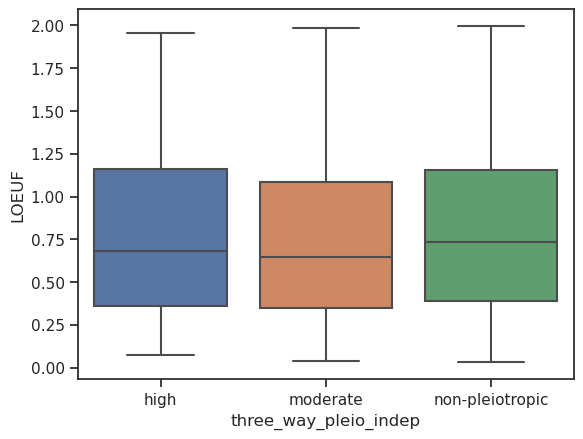

In [150]:
non_hla_annotated['three_way_pleio_indep'] = [emit_class(x) for x in non_hla_annotated['pleio_degree_maxindep']]
sns.boxplot(data=non_hla_annotated, x="three_way_pleio_indep", y="LOEUF")

In [151]:
loeuf_medians = non_hla_annotated.groupby(['three_way_pleio_indep'])['LOEUF'].median()
loeuf_medians

three_way_pleio_indep
high               0.6840
moderate           0.6485
non-pleiotropic    0.7320
Name: LOEUF, dtype: float64

## Analysis using all genes within a 500-kb window from an index

Here, I will repeat the generation of `genes_matrix` with a different rule (all genes in a locus instead of the closest gene to an index SNP) and see if the results will be different.

So far, we know that the closest gene reflects the constraint levels quite well, but does not capture the gene expression differences that we've observed in our previous analyiss.

In [383]:
def create_allgene_bed(pheno, work_dir=work_dir, window_size=500000, clumping=False, pval_cutoff='1e-8'):
    half_win = window_size/2
    if clumping:
        clump_cmd = f'''/home/barbitoff/software/plink --bfile /mnt/data/phenome_proj/EUR_005_nodups \
                    --clump {work_dir}/{pheno} --out {work_dir}/{pheno}_plink \
                    --clump-r2 0.1 --clump-p1 {pval_cutoff} --clump-p2 1e-4 --clump-field P \
                    --allow-no-sex --allow-extra-chr'''
        status = sp.run(clump_cmd, shell=True)
    bed_cmd = f'''awk 'OFS="\t" {{ print $1,$4-{half_win},$4+{half_win},$3,$5 }}' {work_dir}/{pheno}_plink.clumped \
                         | sort -k1,1 -k2,2n | grep -vP '^\s+|CHR' > {work_dir}/{pheno}.loci.bed'''
    status = sp.run(bed_cmd, shell=True)
    gene_cmd = f'''bedtools intersect -wo -a {work_dir}/{pheno}.loci.bed \
                                    -b /mnt/data/phenome_proj/network_cleanup/gencode_formatted.bed \
                                    > {work_dir}/{pheno}.allgenes.bed'''
    status = sp.run(gene_cmd, shell=True)
    print(f'Done {pheno}')

In [378]:
workers = ThreadPoolExecutor(max_workers=16)

In [421]:
workers.map(lambda x: create_allgene_bed(x, window_size=100000), formatted)

awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/continuous-5117-both_sexes-irnt.tsv_plink.clumped' for reading: No such file or directory
awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/continuous-20514-both_sexes.tsv_plink.clumped' for reading: No such file or directory
awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/categorical-670-both_sexes-4.tsv_plink.clumped' for reading: No such file or directory


Done continuous-20514-both_sexes.tsv


<generator object Executor.map.<locals>.result_iterator at 0x7f7aab14c510>

Done categorical-670-both_sexes-4.tsv
Done continuous-5117-both_sexes-irnt.tsv
Done prescriptions-stimulant_laxative|laxative-both_sexes.tsv
Done phecode-555-both_sexes.tsv
Done biomarkers-30750-both_sexes-irnt.tsv


awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/prescriptions-dextropropoxyphene_paracetamol-both_sexes.tsv_plink.clumped' for reading: No such file or directory
/bin/sh: 1: laxative-both_sexes.tsv_plink.clumped: not found
/bin/sh: 1: laxative-both_sexes.tsv.loci.bed: not found
/bin/sh: 1: laxative-both_sexes.tsv.allgenes.bed: not found
/bin/sh: 1: laxative-both_sexes.tsv.loci.bed: not found

Tool:    bedtools intersect (aka intersectBed)
Version: v2.30.0
Summary: Report overlaps between two feature files.

Usage:   bedtools intersect [OPTIONS] -a <bed/gff/vcf/bam> -b <bed/gff/vcf/bam>

	Note: -b may be followed with multiple databases and/or 
	wildcard (*) character(s). 
Options: 
	-wa	Write the original entry in A for each overlap.

	-wb	Write the original entry in B for each overlap.
		- Useful for knowing _what_ A overlaps. Restricted by -f and -r.

	-loj	Perform a "left outer join". That is, for each feature in A
		report each overlap with B.  If no overlaps

...

Done categorical-20547-both_sexes-3.tsv
Done phecode-788-both_sexes.tsv
Done icd10-D44-both_sexes.tsv
Done phecode-327-both_sexes.tsv
Done continuous-4283-both_sexes.tsv
Done icd10-J44-both_sexes.tsv
Done continuous-1279-both_sexes.tsv
Done phecode-747.13-both_sexes.tsv
Done icd10-O43-both_sexes.tsv
Done categorical-2040-both_sexes-2040.tsvDone icd10-H33-both_sexes.tsv

Done prescriptions-albuterol-both_sexes.tsv
Done phecode-575-both_sexes.tsv
Done continuous-3064-both_sexes-irnt.tsv
Done continuous-20150-both_sexes-irnt.tsv
Done prescriptions-terbinafine-both_sexes.tsv
Done phecode-318-both_sexes.tsv
Done continuous-24007-both_sexes-irnt.tsv
Done phecode-361.1-both_sexes.tsv


awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/continuous-5993-both_sexes.tsv_plink.clumped' for reading: No such file or directory
awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/phecode-318-both_sexes.tsv_plink.clumped' for reading: No such file or directory
awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/prescriptions-terbinafine-both_sexes.tsv_plink.clumped' for reading: No such file or directory
awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/phecode-707-both_sexes.tsv_plink.clumped' for reading: No such file or directory
awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/continuous-24007-both_sexes-irnt.tsv_plink.clumped' for reading: No such file or directory
awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/categorical-3751-both_sexes-3751.tsv_plink.clumped' for reading: No such file or directory
awk: fatal: cannot open file `/mnt/data/phenome_pr

Done categorical-4728-both_sexes-4728.tsvDone categorical-20406-both_sexes-20406.tsv
Done continuous-2080-both_sexes.tsv
Done prescriptions-doxycycline-both_sexes.tsv
Done categorical-22619-both_sexes-0.tsv

Done continuous-398-both_sexes.tsv
Done icd10-C44-both_sexes.tsv
Done phecode-280-both_sexes.tsv
Done categorical-3751-both_sexes-3751.tsv
Done continuous-1021-both_sexes.tsv
Done phecode-707-both_sexes.tsv
Done icd10-F10-both_sexes.tsv
Done continuous-2375-both_sexes.tsv
Done continuous-5993-both_sexes.tsv


awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/continuous-20520-both_sexes.tsv_plink.clumped' for reading: No such file or directory
awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/continuous-1021-both_sexes.tsv_plink.clumped' for reading: No such file or directory
awk: fatal: cannot open file `/mnt/data/phenome_proj/evolution/pan_ukb/phecode-535-both_sexes.tsv_plink.clumped' for reading: No such file or directory


Done phecode-535-both_sexes.tsvDone continuous-23118-both_sexes-irnt.tsv

Done continuous-20520-both_sexes.tsv
Done icd10-Z51-both_sexes.tsv


In [152]:
loci_genes = {}
use_trimmed = False
for idx, pheno in enumerate([x for x in passfilter_traits if 'both_sexes' in x]):
    if use_trimmed:
        trim_proximal(gene_bed=f'{pheno}.genes.bed', min_distance=1000000)
        in_file = f'{work_dir}/{pheno}.trimmed.bed' 
    else:
        in_file = f'{work_dir}/{pheno}.allgenes.bed'
    try:
        gene_data = pd.read_csv(in_file, sep='\t', header=None)
    except:
#        print('Broke here')
        continue
    gene_data.columns = ['var_chr', 'var_pos', 'var_end', 'rsid', 'pval', 
                         'chr', 'start', 'end', 'gene_name', 'overlap']
    for chrom, start, end, symbol in zip(gene_data['chr'], gene_data['start'], 
                          gene_data['end'], gene_data['gene_name']):
        if symbol not in loci_genes:
            loci_genes[symbol] = [symbol, chrom, start, end] + [0 for x in passfilter_traits if 'both_sexes' in x]
        loci_genes[symbol][idx + 4] = 1
print(len(loci_genes))
print(loci_genes['LRP1'])

17043
['LRP1', 12, 57522276, 57607134, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0

In [153]:
all_loci_genes = list(loci_genes.values())

In [154]:
loci_gene_matrix = np.array([x[4:] for x in all_loci_genes])
loci_gene_matrix

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]])

In [155]:
loci_gene_meta = {'gene_name': [x[0] for x in all_loci_genes],
            'chr': [x[1] for x in all_loci_genes],
            'start': [x[2] for x in all_loci_genes],
            'end': [x[3] for x in all_loci_genes]}
loci_gene_meta = pd.DataFrame(loci_gene_meta)
loci_gene_meta.head()

,gene_name,chr,start,end
0,RP3-469D22.1,1,25725203,25725771
1,AL031284.1,1,25732722,25732780
2,RHCE,1,25688740,25756683
3,TMEM57,1,25757388,25826700
4,TMEM61,1,55446465,55457966


In [156]:
loci_merged = []
for i in range(optimal_n):
    pheno_names = [clean_pheno_names[idx] for idx, n in enumerate(clusters) if n == i]
    if 'continuous-21001' in pheno_names:
        print(pheno_names)
    pheno_idx = [idx for idx, pheno_name in enumerate(clean_pheno_names) if pheno_name in pheno_names]
    locus_gene_cluster = np.apply_along_axis(lambda x: 1 if 1 in x else 0, 1, loci_gene_matrix[:,pheno_idx])
    loci_merged.append(locus_gene_cluster)
loci_gene_cluster_matrix = np.array(loci_merged).T
loci_gene_cluster_matrix.shape

['continuous-49', 'continuous-23124', 'continuous-23128', 'continuous-23120', 'continuous-23123', 'continuous-23116', 'continuous-23099', 'continuous-21001', 'continuous-23127', 'biomarkers-30710', 'continuous-23100', 'continuous-23115', 'continuous-23119', 'continuous-23112', 'continuous-23104', 'continuous-23111']


(17043, 212)

In [157]:
loci_gene_meta.loc[loci_gene_meta['gene_name'] == 'HLA-A']

,gene_name,chr,start,end
1570,HLA-A,6,29909037,29913661


In [158]:
hla_checker(1586, gene_meta=loci_gene_meta)

False

In [159]:
non_hla_loci_genes = [idx for idx, gene in enumerate(loci_gene_cluster_matrix) if hla_checker(idx,
                                                gene_meta=loci_gene_meta)]
len(non_hla_loci_genes)

16569

In [160]:
non_hla_loci_matrix = loci_gene_cluster_matrix[non_hla_loci_genes, :]

In [161]:
non_hla_loci_matrix.shape

(16569, 212)

In [162]:
non_hla_loci_meta = loci_gene_meta.iloc[non_hla_loci_genes, :].copy()

In [163]:
non_hla_loci_meta.shape

(16569, 4)

In [164]:
non_hla_loci_meta['pleio_degree'] = np.apply_along_axis(sum, 1, non_hla_loci_matrix)

In [165]:
non_hla_loci_meta.head()

,gene_name,chr,start,end,pleio_degree
0,RP3-469D22.1,1,25725203,25725771,7
1,AL031284.1,1,25732722,25732780,7
2,RHCE,1,25688740,25756683,7
3,TMEM57,1,25757388,25826700,7
4,TMEM61,1,55446465,55457966,1


In [166]:
pdeg_cnt_loci = Counter(non_hla_loci_meta['pleio_degree'])
for i in range(20):
    print(f'{i + 1}: {pdeg_cnt_loci[i + 1]}')

1: 7754
2: 4093
3: 1865
4: 1058
5: 627
6: 407
7: 262
8: 169
9: 98
10: 47
11: 54
12: 52
13: 21
14: 20
15: 7
16: 6
17: 1
18: 16
19: 2
20: 3


<AxesSubplot:xlabel='pleio_degree', ylabel='Count'>

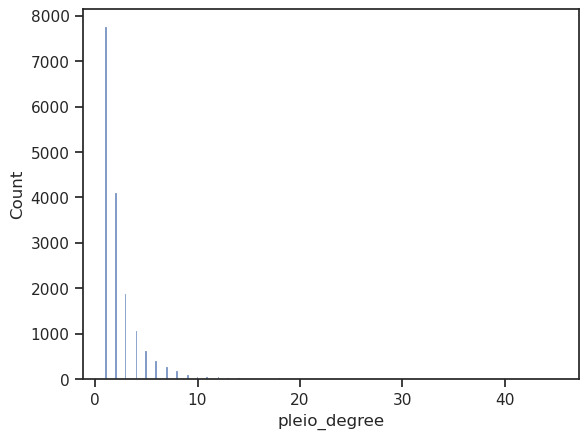

In [167]:
sns.histplot(non_hla_loci_meta['pleio_degree'])

In [168]:
non_hla_loci_meta.to_csv('/mnt/data/phenome_proj/evolution/non_hla_panukb_locuswide_pleiotropy.tsv', 
                         sep='\t', index=False)

In [169]:
non_hla_loci_meta['three_way_pleiotropic'] = [emit_class(x) for x in non_hla_loci_meta['pleio_degree']]

In [170]:
Counter(non_hla_loci_meta['three_way_pleiotropic'])

Counter({'high': 1799, 'non-pleiotropic': 7754, 'moderate': 7016})

In [171]:
non_hla_loci_meta['LOEUF'] = [loeuf[x] for x in non_hla_loci_meta['gene_name']]
non_hla_loci_meta['pLI'] = [pli[x] for x in non_hla_loci_meta['gene_name']]
non_hla_loci_meta.head()

,gene_name,chr,start,end,pleio_degree,three_way_pleiotropic,LOEUF,pLI
0,RP3-469D22.1,1,25725203,25725771,7,high,NaN,NaN
1,AL031284.1,1,25732722,25732780,7,high,NaN,NaN
2,RHCE,1,25688740,25756683,7,high,0.768,0.001163
3,TMEM57,1,25757388,25826700,7,high,0.259,0.997570
4,TMEM61,1,55446465,55457966,1,non-pleiotropic,1.845,0.000061


<AxesSubplot:xlabel='three_way_pleiotropic', ylabel='LOEUF'>

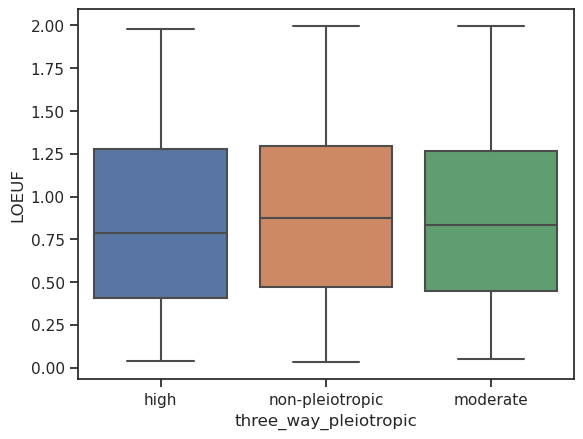

In [172]:
sns.boxplot(data=non_hla_loci_meta, x="three_way_pleiotropic", y="LOEUF")

In [173]:
loeuf_medians = non_hla_loci_meta.groupby(['three_way_pleiotropic'])['LOEUF'].median()
loeuf_medians

three_way_pleiotropic
high               0.790
moderate           0.836
non-pleiotropic    0.873
Name: LOEUF, dtype: float64

In [174]:
print('a')

a


## Merging two kinds of data into a single file

In [175]:
non_hla_meta.head()

,gene_name,chr,start,end,pleio_degree,pleio_degree_maxindep
0,TMEM57,1,25757388,25826700,5,6
1,BSND,1,55464606,55476556,1,4
2,PCSK9,1,55505221,55530525,1,4
3,RP11-101C11.1,1,55683534,55699850,1,4
4,USP1,1,62901968,62917475,5,5


In [176]:
non_hla_loci_meta.head()

,gene_name,chr,start,end,pleio_degree,three_way_pleiotropic,LOEUF,pLI
0,RP3-469D22.1,1,25725203,25725771,7,high,NaN,NaN
1,AL031284.1,1,25732722,25732780,7,high,NaN,NaN
2,RHCE,1,25688740,25756683,7,high,0.768,0.001163
3,TMEM57,1,25757388,25826700,7,high,0.259,0.997570
4,TMEM61,1,55446465,55457966,1,non-pleiotropic,1.845,0.000061


In [177]:
pleiotropy_data_total = non_hla_loci_meta[['gene_name', 'pleio_degree']].copy()
pleiotropy_data_total.columns = ['gene_name', 'pleio_degree_locuswide']
pleiotropy_data_total = pleiotropy_data_total.merge(non_hla_meta,
                on='gene_name', how='outer')
pleiotropy_data_total = pleiotropy_data_total[['gene_name', 'pleio_degree',
                'pleio_degree_maxindep', 'pleio_degree_locuswide']]
def emit_nan(val):
    if not np.isnan(val) and val == 0:
        return np.nan
    else: return val
for pleio_col in pleiotropy_data_total.columns[1:]:
    pleiotropy_data_total[pleio_col] = [emit_nan(x) for x in pleiotropy_data_total[pleio_col]]
pleiotropy_data_total.head()

,gene_name,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide
0,RP3-469D22.1,NaN,NaN,7.0
1,AL031284.1,NaN,NaN,7.0
2,RHCE,6.0,2.0,7.0
3,TMEM57,5.0,6.0,7.0
4,TMEM61,NaN,NaN,1.0


In [178]:
pleiotropy_data_total.to_csv('/mnt/data/phenome_proj/evolution/non_hla_panukb_pleiotropy_allTypes.tsv',
                            sep='\t', index=False)

## Analysis of the network modularity

To run the network modularity analysis, we need to convert the data into an edge list. We'll use the simplest possible way of doing it (ignoring gene IDs)

In [179]:
closest_edgelist_file = '/mnt/data/phenome_proj/evolution/panUKB_closest_edgelist.txt'
all_edgelist_file = '/mnt/data/phenome_proj/evolution/panUKB_all_edgelist.txt'

In [180]:
with open(closest_edgelist_file, 'w') as el_file:
    for idx, gene_data in enumerate(gene_cluster_matrix):
        for cl_idx, clust_assoc in enumerate(gene_data):
            if clust_assoc > 0:
                el_file.write(f'{idx}\t{cl_idx}\n')

In [181]:
with open(all_edgelist_file, 'w') as el_file:
    for idx, gene_data in enumerate(loci_gene_cluster_matrix):
        for cl_idx, clust_assoc in enumerate(gene_data):
            if clust_assoc > 0:
                el_file.write(f'{idx}\t{cl_idx}\n')

In [5]:
import condor

In [27]:
closest_data = pd.read_csv(closest_edgelist_file, sep='\t', header=None)
closest_data.columns = ['src', 'tg']
closest_data.head()

,src,tg
0,0,377
1,1,9
2,1,54
3,1,70
4,1,99


In [28]:
closest_data.dtypes

src    int64
tg     int64
dtype: object

In [29]:
import importlib
condor = importlib.reload(condor)

In [30]:
co = condor.condor_object(dataframe=closest_data)

Object creation:
Unweighted network. Weights initialized as 1.
  Elapsed time: 0.02 sec.


In [31]:
co.initial_community()

Initial community structure without projection:
Initial modularity:  0.5615352843203866
  Elapsed time: 0.12 sec.


In [32]:
co.modularity

0.5615352843203866

In [34]:
hpo_net_file = '/mnt/data/phenome_proj/evolution/hpo_netowrk.txt'
mgd_net_file = '/mnt/data/phenome_proj/evolution/mgd_netowrk.txt'

hpo_data = pd.read_csv(hpo_net_file, sep='\t', header=None)
hpo_data.columns = ['src', 'tg']
hpo_co = condor.condor_object(dataframe=hpo_data)
hpo_co.initial_community()
print(f'HPO modularity is {hpo_co.modularity}')

mgd_data = pd.read_csv(mgd_net_file, sep='\t', header=None)
mgd_data.columns = ['src', 'tg']
mgd_co = condor.condor_object(dataframe=mgd_data)
mgd_co.initial_community()
print(f'MGD modularity is {mgd_co.modularity}')

Object creation:
Unweighted network. Weights initialized as 1.
  Elapsed time: 0.04 sec.
Initial community structure without projection:
Initial modularity:  0.1223184528896459
  Elapsed time: 0.04 sec.
HPO modularity is 0.1223184528896459
Object creation:
Unweighted network. Weights initialized as 1.
  Elapsed time: 0.06 sec.
Initial community structure without projection:
Initial modularity:  0.20528212584322814
  Elapsed time: 0.22 sec.
MGD modularity is 0.20528212584322814
